# Model Evaluation

Compare all three sentiment models (TF-IDF, LSTM, BERT) on the test set.

## Imports

In [11]:
import os
import sys
import pandas as pd
import pickle
import torch

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model


## Load Test Data

In [4]:
test_df = pd.read_csv('data/test.csv').dropna()
# Sample for faster evaluation — remove this for full evaluation
# test_df = test_df.sample(500, random_state=42)
print(f"Test set size: {len(test_df)}")
test_df.head()

Test set size: 7500


,review,sentiment
0,My parents used to rent a lot of horror movies...,negative
1,I got a chance to see this movie at an early s...,positive
2,Well the previews looked funny and I usually d...,negative
3,As a true lover of film I must advise you to a...,negative
4,I first saw this movie as a teenager when it c...,positive


## 1. Evaluate TF-IDF + Logistic Regression

In [8]:
print("--- Evaluating TF-IDF + LR ---")
model_dir = 'models/tfidf_lr'

if os.path.exists(model_dir):
    with open(os.path.join(model_dir, 'tfidf_vectorizer.pkl'), 'rb') as f:
        vectorizer = pickle.load(f)
    with open(os.path.join(model_dir, 'lr_model.pkl'), 'rb') as f:
        lr_model = pickle.load(f)
    
    X_test = test_df['review'].values
    y_test = (test_df['sentiment'] == 'positive').astype(int).values
    
    X_test_vec = vectorizer.transform(X_test)
    tfidf_preds = lr_model.predict(X_test_vec)
    
    print(f"Accuracy: {accuracy_score(y_test, tfidf_preds):.4f}")
    print(classification_report(y_test, tfidf_preds, target_names=['negative', 'positive']))
else:
    print("TF-IDF model not found. Train it first using 02_tfidf_model.ipynb")

--- Evaluating TF-IDF + LR ---
Accuracy: 0.9035
              precision    recall  f1-score   support

    negative       0.92      0.88      0.90      3750
    positive       0.89      0.93      0.91      3750

    accuracy                           0.90      7500
   macro avg       0.90      0.90      0.90      7500
weighted avg       0.90      0.90      0.90      7500



## 2. Evaluate LSTM

In [7]:
print("--- Evaluating LSTM ---")
model_dir = "models/lstm_model.keras"

if os.path.exists(model_dir):
    lstm_model = load_model(model_dir)

    with open('models/lstm_tokenizer.pkl', 'rb') as handle:
        tokenizer = pickle.load(handle)

    with open('models/lstm_encoder.pkl', 'rb') as handle:
        encoder = pickle.load(handle)

    column_1 = "review"
    column_2 = "sentiment"

    info = test_df[column_1].astype(str).str.lower().str.strip().tolist()
    sentiment = test_df[column_2].tolist()

    eval_label = encoder.transform(sentiment)
    sequences = tokenizer.texts_to_sequences(info)
    eval_pad = pad_sequences(sequences, maxlen=500, padding='post', truncating='post')

    eval_loss, eval_acc = lstm_model.evaluate(eval_pad, eval_label, verbose=0)
    print(f"Test loss is {eval_loss:.4f} while Test accuracy is {eval_acc:.4f}")
    
    batch_size = 16
    preds_raw = lstm_model.predict(eval_pad, batch_size=batch_size)
    lstm_preds = (preds_raw.squeeze() >= 0.5).astype(int)
    
    print(f"Accuracy: {accuracy_score(eval_label, lstm_preds):.4f}")

    print(classification_report(eval_label, lstm_preds, target_names=[str(c) for c in encoder.classes_]))
    
else:
    print("LSTM model not found. Train first using your LSTM training notebook.")
    


--- Evaluating LSTM ---
Test loss is 0.3394 while Test accuracy is 0.8561
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step
Accuracy: 0.8561
              precision    recall  f1-score   support

    negative       0.85      0.87      0.86      3750
    positive       0.87      0.84      0.85      3750

    accuracy                           0.86      7500
   macro avg       0.86      0.86      0.86      7500
weighted avg       0.86      0.86      0.86      7500



## 3. Evaluate BERT

In [9]:
print("--- Evaluating BERT ---")
model_dir = 'models/bert_sentiment'

# Also check for 'models/bert/best_model' (legacy path)
if not os.path.exists(model_dir):
    model_dir = 'models/bert/best_model'

if os.path.exists(model_dir):
    tokenizer = AutoTokenizer.from_pretrained(model_dir)
    bert_model = AutoModelForSequenceClassification.from_pretrained(model_dir)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    bert_model.to(device)
    bert_model.eval()
    
    X_test = test_df['review'].values
    y_test = (test_df['sentiment'] == 'positive').astype(int).values
    
    bert_preds = []
    batch_size = 16
    with torch.no_grad():
        for i in range(0, len(X_test), batch_size):
            batch_texts = X_test[i:i+batch_size].tolist()
            inputs = tokenizer(batch_texts, padding=True, truncation=True, max_length=256, return_tensors="pt").to(device)
            outputs = bert_model(**inputs)
            logits = outputs.logits
            batch_preds = torch.argmax(logits, dim=-1).cpu().numpy()
            bert_preds.extend(batch_preds)
    
    print(f"Accuracy: {accuracy_score(y_test, bert_preds):.4f}")
    print(classification_report(y_test, bert_preds, target_names=['negative', 'positive']))
else:
    print("BERT model not found. Train first using 04_bert_model.ipynb")

--- Evaluating BERT ---


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 7126.29it/s]


Accuracy: 0.9120
              precision    recall  f1-score   support

    negative       0.93      0.90      0.91      3750
    positive       0.90      0.93      0.91      3750

    accuracy                           0.91      7500
   macro avg       0.91      0.91      0.91      7500
weighted avg       0.91      0.91      0.91      7500



# 4. Graphing the Results

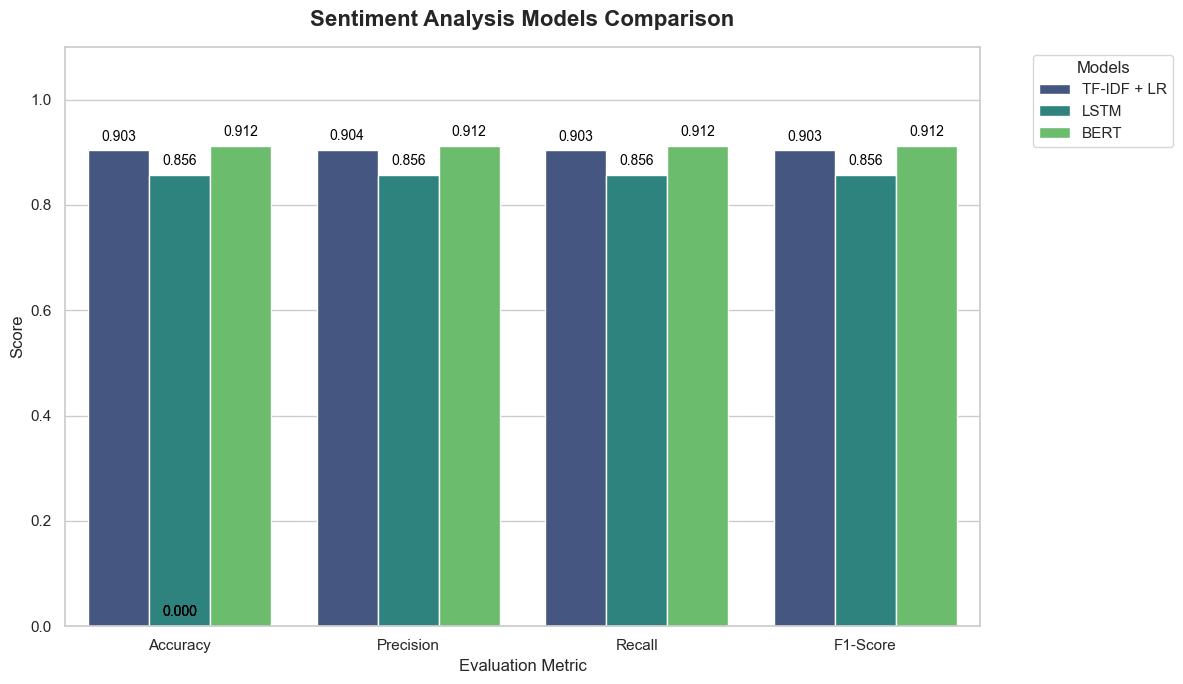

,Model,Accuracy,Precision,Recall,F1-Score
0,TF-IDF + LR,0.903467,0.904357,0.903467,0.903413
1,LSTM,0.856133,0.856353,0.856133,0.856111
2,BERT,0.912000,0.912395,0.912000,0.911979


In [12]:
model_predictions = {
    'TF-IDF + LR': tfidf_preds,
    'LSTM': lstm_preds,
    'BERT': bert_preds
}

metrics_data = []

for model_name, preds in model_predictions.items():
    metrics_data.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds, average='macro'),
        'Recall': recall_score(y_test, preds, average='macro'),
        'F1-Score': f1_score(y_test, preds, average='macro')
    })

df_metrics = pd.DataFrame(metrics_data)

df_melted = df_metrics.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df_melted, 
    x='Metric', 
    y='Score', 
    hue='Model', 
    palette='viridis' 
)

plt.title('Sentiment Analysis Models Comparison', fontsize=16, fontweight='bold', pad=15)
plt.ylim(0, 1.1) 
plt.ylabel('Score', fontsize=12)
plt.xlabel('Evaluation Metric', fontsize=12)

plt.legend(title='Models', bbox_to_anchor=(1.05, 1), loc='upper left')

for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                fontsize=10, color='black', xytext=(0, 5), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

display(df_metrics)